# Tarea 1: Demographic Profile & Migration Landscape

- **Integrantes:** Ignacio Corvalán y Valentina Cornejo
- **Profesor:** Leo Ferres
- **Ayudante:** Antuan Vayisqui
- **Región asignada:** Región Metropolitana
- **Comuna asignada:** La Florida

## Objetivo
En esta tarea se construye un perfil demográfico y migratorio de la comuna asignada usando los microdatos del Censo 2024. Para ello, se cargan y unen las tablas de vivienda, hogar y persona, y luego se calculan indicadores demográficos, migratorios y espaciales.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

## Part 0: Data Loading & Joins

En esta sección se cargan las tablas de viviendas, hogares y personas del Censo 2024. Luego se filtran para trabajar únicamente con la comuna asignada, La Florida, y finalmente se unen en una sola base de análisis.

In [ ]:
MY_COMUNAS = [13110]

In [ ]:
cols_vivienda = [
    "id_vivienda", "region", "provincia", "comuna"
]

cols_hogar = [
    "id_vivienda", "id_hogar"
]

cols_persona = [
    "id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
    "p27_nacionalidad_esp", "p25_lug_nacimiento_rec",
    "p24_lug_resid5", "p25_lug_nacimiento", "p26_llegada_periodo",
    "escolaridad", "cine11", "sit_fuerza_trabajo",
    "cod_ciuo", "cod_caenes", "p45_medio_transporte"
]

vivienda = pd.read_parquet("viviendas_censo2024.parquet", columns=cols_vivienda)
hogar = pd.read_parquet("hogares_censo2024.parquet", columns=cols_hogar)
persona = pd.read_parquet("personas_censo2024.parquet", columns=cols_persona)

## Parte 0.1: Carga de datos

Se cargaron las tres tablas del Censo 2024: viviendas, hogares y personas. Para optimizar memoria, se seleccionaron únicamente las columnas necesarias para desarrollar los indicadores y visualizaciones solicitadas en la tarea.

In [ ]:
print("Vivienda:", vivienda.shape)
print("Hogar:", hogar.shape)
print("Persona:", persona.shape)

Vivienda: (7664466, 4)
Hogar: (6622597, 2)
Persona: (18480432, 16)


In [ ]:
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

## Parte 0.2: Filtrado por comuna

Se filtró primero la tabla de viviendas usando el código de la comuna asignada. Luego, a partir de las viviendas filtradas, se seleccionaron los hogares y personas asociados. Este procedimiento permite trabajar solo con la población que se nos asigno.

In [ ]:
print("Filas en vivienda filtrada:", len(viv))
print("Filas en hogar filtrada:", len(hog))
print("Filas en persona filtrada:", len(per))

Filas en vivienda filtrada: 143924
Filas en hogar filtrada: 133971
Filas en persona filtrada: 374836


In [ ]:
df = (
    per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")
       .merge(viv, on="id_vivienda", how="left")
)

assert len(df) == len(per), "Row count mismatch after join!"

## Parte 0.3: Unión de tablas

Se realizó un left join entre personas y hogares usando `id_vivienda` e `id_hogar`, y luego se unió la tabla resultante con viviendas usando `id_vivienda`. Después de la unión, se verificó que la cantidad de filas coincidiera con el número de personas filtradas, asegurando que no se perdieron ni duplicaron registros.

In [ ]:
print("Shape final del dataframe unido:", df.shape)
df.info()

Shape final del dataframe unido: (374836, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374836 entries, 0 to 374835
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             374836 non-null  int32  
 1   id_hogar                374836 non-null  int32  
 2   id_persona              374836 non-null  int32  
 3   sexo                    374836 non-null  int32  
 4   edad                    374836 non-null  int32  
 5   p27_nacionalidad_esp    374836 non-null  int32  
 6   p25_lug_nacimiento_rec  374836 non-null  int32  
 7   p24_lug_resid5          374836 non-null  int32  
 8   p25_lug_nacimiento      374836 non-null  int32  
 9   p26_llegada_periodo     36685 non-null   float64
 10  escolaridad             374836 non-null  int32  
 11  cine11                  374836 non-null  int32  
 12  sit_fuerza_trabajo      316074 non-null  float64
 13  cod_ciuo                1830

In [ ]:
for col in ["edad", "escolaridad", "sit_fuerza_trabajo", "p24_lug_resid5", "p26_llegada_periodo"]:
    if col in df.columns:
        df[col] = df[col].replace(-99, np.nan)

In [ ]:
df = df.rename(columns={"comuna": "codigo_comuna"})
df["nombre_comuna"] = np.where(df["codigo_comuna"] == 13110, "La Florida", "Otra")

df[["codigo_comuna", "nombre_comuna"]].drop_duplicates().sort_values("codigo_comuna")

,codigo_comuna,nombre_comuna
0,13110,La Florida


## Parte 1.1: Pirámide poblacional

En esta sección se construye una pirámide poblacional para la comuna de La Florida.

Para ello, se agrupa a la población por sexo y tramos de edad de 5 años. Además, se distingue entre personas nacidas en Chile y personas nacidas en el extranjero, utilizando la variable `p25_lug_nacimiento_rec`.

In [ ]:
# Crear copia para trabajar la pirámide
df_piramide = df.copy()

# Asegurar que edad sea numérica
df_piramide["edad"] = pd.to_numeric(df_piramide["edad"], errors="coerce")

# Eliminar edades faltantes
df_piramide = df_piramide[df_piramide["edad"].notna()].copy()

# Crear tramos de edad de 5 años
bins = list(range(0, 90, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 85, 5)] + ["85+"]

df_piramide["grupo_edad"] = pd.cut(
    df_piramide["edad"],
    bins=bins,
    labels=labels,
    right=False
)

df_piramide[["edad", "grupo_edad"]].head()

,edad,grupo_edad
0,55,55-59
1,56,55-59
2,22,20-24
3,33,30-34
4,60,60-64


In [ ]:
df_piramide["p25_lug_nacimiento_rec"].value_counts(dropna=False).sort_index()

,count
p25_lug_nacimiento_rec,
-99,2811
1,335340
2,36685


In [ ]:
df_piramide["origen"] = df_piramide["p25_lug_nacimiento_rec"].map({
    1: "Chile",
    2: "Extranjero"
})

df_piramide["origen"].value_counts(dropna=False)

,count
origen,
Chile,335340
Extranjero,36685
NaN,2811


In [ ]:
df_piramide["sexo"].value_counts(dropna=False).sort_index()

,count
sexo,
1,178461
2,196375


In [ ]:
df_piramide["sexo_desc"] = df_piramide["sexo"].map({
    1: "Hombres",
    2: "Mujeres"
})

Creamos la variable sexo

In [ ]:
tabla_piramide = (
    df_piramide
    .dropna(subset=["grupo_edad", "sexo_desc", "origen"])
    .groupby(["origen", "grupo_edad", "sexo_desc"], observed=False)
    .size()
    .reset_index(name="poblacion")
)

tabla_piramide.head(10)

,origen,grupo_edad,sexo_desc,poblacion
0,Chile,0-4,Hombres,7358
1,Chile,0-4,Mujeres,7141
2,Chile,5-9,Hombres,9543
3,Chile,5-9,Mujeres,9123
4,Chile,10-14,Hombres,10495
5,Chile,10-14,Mujeres,10037
6,Chile,15-19,Hombres,10533
7,Chile,15-19,Mujeres,10229
8,Chile,20-24,Hombres,11835
9,Chile,20-24,Mujeres,11391


Armamos la tabla para la piramide

# **Piramide Poblacional Nacidos en Chile**

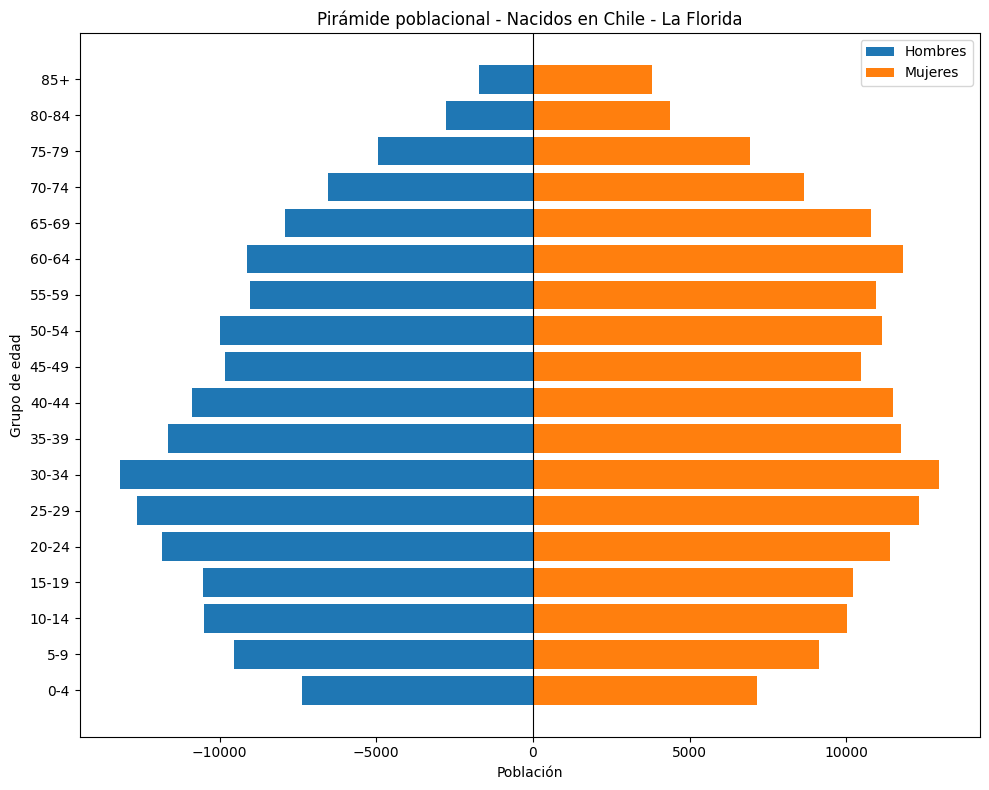

In [ ]:
chile = tabla_piramide[tabla_piramide["origen"] == "Chile"].copy()

pivot_chile = chile.pivot(
    index="grupo_edad",
    columns="sexo_desc",
    values="poblacion"
).fillna(0)

pivot_chile["Hombres"] = -pivot_chile["Hombres"]

plt.figure(figsize=(10, 8))
plt.barh(pivot_chile.index.astype(str), pivot_chile["Hombres"], label="Hombres")
plt.barh(pivot_chile.index.astype(str), pivot_chile["Mujeres"], label="Mujeres")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pirámide poblacional - Nacidos en Chile - La Florida")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.legend()
plt.tight_layout()
plt.show()


# **Piramide Poblacional gente extranjera**

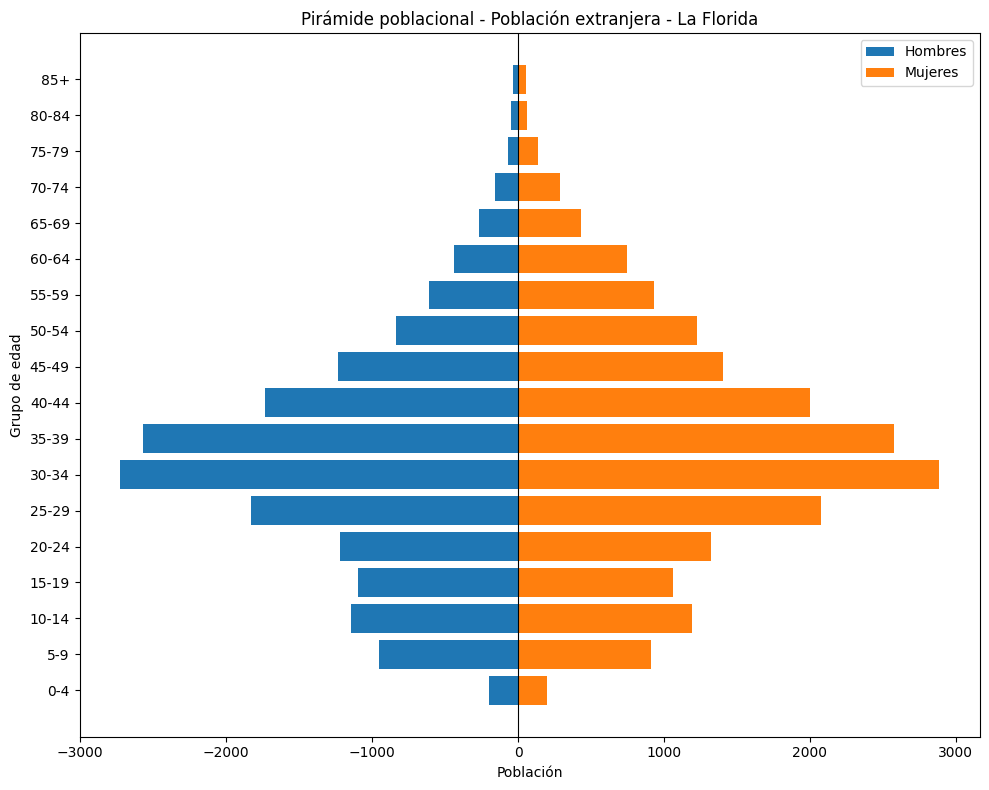

In [ ]:
extr = tabla_piramide[tabla_piramide["origen"] == "Extranjero"].copy()

pivot_extr = extr.pivot(
    index="grupo_edad",
    columns="sexo_desc",
    values="poblacion"
).fillna(0)

pivot_extr["Hombres"] = -pivot_extr["Hombres"]

plt.figure(figsize=(10, 8))
plt.barh(pivot_extr.index.astype(str), pivot_extr["Hombres"], label="Hombres")
plt.barh(pivot_extr.index.astype(str), pivot_extr["Mujeres"], label="Mujeres")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pirámide poblacional - Población extranjera - La Florida")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.legend()
plt.tight_layout()
plt.show()

## Parte 1.1: Pirámide poblacional

Se construyó una pirámide poblacional para la comuna de La Florida, agrupando a la población en tramos de edad de 5 años y diferenciando por sexo.

Además, se separó la población nacida en Chile de la población nacida en el extranjero, utilizando la variable `p25_lug_nacimiento_rec`. Esto permite comparar la estructura etaria y por sexo de ambos grupos.

### Interpretación


## Parte 1.2: Razón de dependencia

La razón de dependencia mide la relación entre la población en edades potencialmente dependientes y la población en edad de trabajar.

Para este cálculo, se considera como población dependiente a las personas de 0 a 14 años y de 65 años o más, mientras que la población en edad de trabajar corresponde a las personas entre 15 y 64 años.

In [ ]:
# Crear grupos para razón de dependencia
df_dependencia = df.copy()
df_dependencia["edad"] = pd.to_numeric(df_dependencia["edad"], errors="coerce")
df_dependencia = df_dependencia[df_dependencia["edad"].notna()].copy()

dependientes = df_dependencia[
    (df_dependencia["edad"] <= 14) | (df_dependencia["edad"] >= 65)
].shape[0]

trabajo = df_dependencia[
    (df_dependencia["edad"] >= 15) & (df_dependencia["edad"] <= 64)
].shape[0]

razon_dependencia = (dependientes / trabajo) * 100

print("Población dependiente:", dependientes)
print("Población en edad de trabajar:", trabajo)
print("Razón de dependencia:", round(razon_dependencia, 2))

Población dependiente: 119509
Población en edad de trabajar: 255327
Razón de dependencia: 46.81


### Interpretación

La razón de dependencia indica cuántas personas en edades potencialmente dependientes existen por cada 100 personas en edad de trabajar.

Este indicador permite aproximarse a la carga demográfica que enfrenta la población activa de la comuna.

## Parte 1.3: Distribución del tamaño del hogar

En esta sección se analiza la distribución del tamaño de los hogares de la comuna de La Florida, a partir del número de personas que integran cada hogar.

In [ ]:
# Calcular tamaño del hogar
tam_hogar = (
    df.groupby(["id_vivienda", "id_hogar"])
      .size()
      .reset_index(name="tam_hogar")
)

tam_hogar["tam_hogar"].describe()

,tam_hogar
count,133971.000000
mean,2.797889
std,1.548553
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,97.000000


In [ ]:
# Distribución del tamaño del hogar
dist_tam_hogar = (
    tam_hogar["tam_hogar"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dist_tam_hogar.columns = ["tam_hogar", "cantidad_hogares"]
dist_tam_hogar

,tam_hogar,cantidad_hogares
0,1,27159
1,2,37619
2,3,30688
3,4,22641
4,5,10025
5,6,3544
6,7,1325
7,8,551
8,9,194
9,10,99


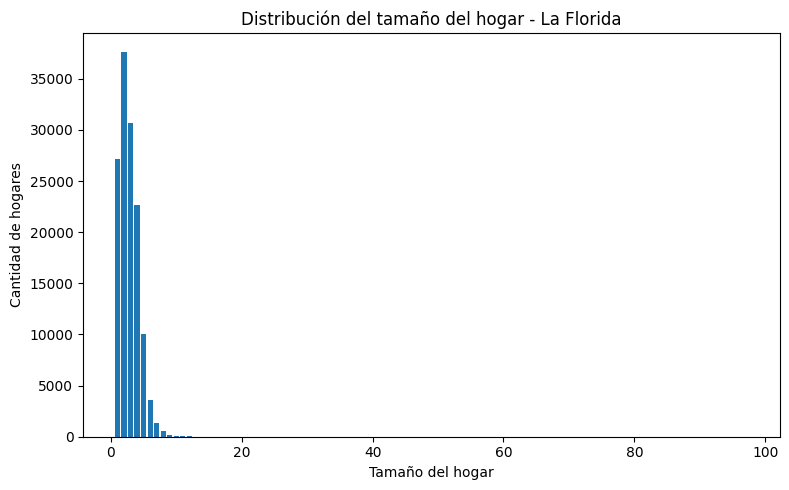

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(dist_tam_hogar["tam_hogar"], dist_tam_hogar["cantidad_hogares"])
plt.title("Distribución del tamaño del hogar - La Florida")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Cantidad de hogares")
plt.tight_layout()
plt.show()

# Interpretación
La distribución del tamaño del hogar en la comuna de La Florida muestra que predominan los hogares de tamaño pequeño y mediano, especialmente aquellos compuestos por 2, 3 y 4 personas.

A medida que aumenta el número de integrantes por hogar, la frecuencia disminuye de forma importante. Esto sugiere que en la comuna son menos comunes los hogares muy numerosos.

## Parte 1.4: Escolaridad promedio

En esta sección se calcula el promedio de escolaridad de la población de la comuna de La Florida, excluyendo los valores faltantes o inválidos.

In [ ]:
df_escolaridad = df.copy()

df_escolaridad["escolaridad"] = pd.to_numeric(df_escolaridad["escolaridad"], errors="coerce")
df_escolaridad["escolaridad"] = df_escolaridad["escolaridad"].replace(-99, np.nan)

prom_escolaridad = df_escolaridad["escolaridad"].mean()

print("Escolaridad promedio:", round(prom_escolaridad, 2))

Escolaridad promedio: 11.27


### Interpretación
La escolaridad propmedio de la comuna de la Florida es de 11.27 años, esto quiere decir que en promedio la poblacion ha cursado un nivel educacional cercano a la enseñanza media completa que son aproximadamente 14 años. Esto muestra que la comuna presenta un nivel de formación relativamente alto, ya que el promedio cursa completamente la educación básica y casi la mitad de la educación media.Sin embargo, al ser un promedio, no representa a que toda la población tenga el mismo nivel educativo.

In [ ]:
df["sit_fuerza_trabajo"].value_counts(dropna=False).sort_index()

,count
sit_fuerza_trabajo,
1.0,183056
2.0,15555
3.0,115346
NaN,60879


Con este resultado, utilizaremos el 1.0 = ocupado ; 2.0= desocupado ; 3.0= fuera de la fuerza de trabajo y Nan sin dato

## Parte 1.5 : Tasa de empleo
En esta parte calcularemos la tasa de empleo de la comuna de La Florida.  Para ello, se considera como población ocupada a las personas clasificadas como ocupadas en la variable `sit_fuerza_trabajo`, y se divide por la población en edad de trabajar, definida entre 15 y 64 años.

In [ ]:
df_empleo = df.copy()

df_empleo["edad"] = pd.to_numeric(df_empleo["edad"], errors="coerce")
df_empleo["sit_fuerza_trabajo"] = pd.to_numeric(df_empleo["sit_fuerza_trabajo"], errors="coerce")

# Población en edad de trabajar
pet = df_empleo[(df_empleo["edad"] >= 15) & (df_empleo["edad"] <= 64)].copy()

# Ocupados dentro de la población en edad de trabajar
ocupados = pet[pet["sit_fuerza_trabajo"] == 1].shape[0]

# Total población en edad de trabajar
total_pet = pet.shape[0]

tasa_empleo = (ocupados / total_pet) * 100

print("Ocupados:", ocupados)
print("Población en edad de trabajar:", total_pet)
print("Tasa de empleo:", round(tasa_empleo, 2))

Ocupados: 171432
Población en edad de trabajar: 255327
Tasa de empleo: 67.14


### Interpretación
Los resultados obtenidos muestran que en la comuna de La Florida hay 171.432 personas ocupadas dentro de un total de 255327 personas en edad para trabajar, lo que da un porcentaje de tasa de empleo del 67.14%. Esto nos muestra que cerca de un tercio de la poblaciónen edad de trabajar no aparece ocupada bajo este indicador. En ese grupo se pueden encontrar personas desocupadas, personas duera de la fuerza de trabajo o casos sin informacion, por lo que la tasa de empleo no debe interpretarse como ausencia total de actividad.

## Parte 2.1: Porcentaje de población nacida en el extranjero

En esta sección se calcula el porcentaje de población nacida en el extranjero en la comuna de La Florida, utilizando la variable `p25_lug_nacimiento_rec`.

Se considera como población extranjera a quienes tienen código 2 en esta variable, mientras que el código 1 corresponde a personas nacidas en Chile.

In [ ]:
df_mig = df.copy()

# Estandarizar variable de origen
df_mig["origen"] = df_mig["p25_lug_nacimiento_rec"].map({
    1: "Chile",
    2: "Extranjero"
})

tabla_foreign = (
    df_mig.groupby(["codigo_comuna", "nombre_comuna"], dropna=False)
    .agg(
        pop_total=("id_persona", "count"),
        pop_foreign=("origen", lambda x: (x == "Extranjero").sum())
    )
    .reset_index()
)

tabla_foreign["pct_foreign"] = (
    tabla_foreign["pop_foreign"] / tabla_foreign["pop_total"] * 100
)

tabla_foreign

,codigo_comuna,nombre_comuna,pop_total,pop_foreign,pct_foreign
0,13110,La Florida,374836,36685,9.786947


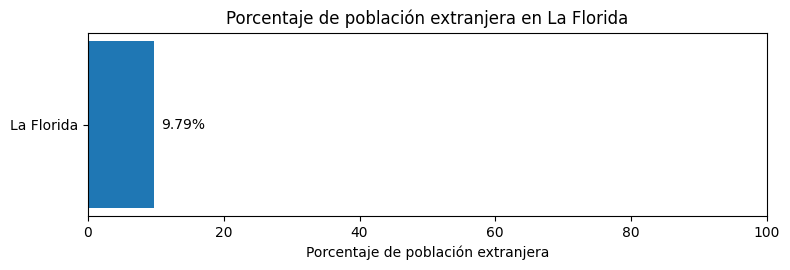

In [ ]:
valor = tabla_foreign.loc[0, "pct_foreign"]
comuna = tabla_foreign.loc[0, "nombre_comuna"]

plt.figure(figsize=(8, 2.8))
plt.barh([comuna], [valor])
plt.xlim(0, 100)
plt.xlabel("Porcentaje de población extranjera")
plt.title("Porcentaje de población extranjera en La Florida")

plt.text(valor + 1, 0, f"{valor:.2f}%", va="center")

plt.tight_layout()
plt.show()

### Interpretación
Los resultados obtenidos anteriormente muestran que en La Florida hay una población total de 374836	de las cuales 36685 personas corresponden a personas nacidas en el extranjero. Este resultado equivale aproximadamente al 9.79% del total de la comuna. Este resultado indica que la población extranjera en la comuna es significativa ya que casi 1 de cada 10 personas que vive en La Floridanació fuera de Chile.


## Parte 2.2: Top 10 nacionalidades

En esta sección se identifican las 10 nacionalidades más frecuentes entre la población nacida en el extranjero residente en La Florida, utilizando la variable `p27_nacionalidad_esp`.

In [ ]:
top_codigos_nac = (
    df_mig[df_mig["origen"] == "Extranjero"]["p27_nacionalidad_esp"]
    .replace(-99, np.nan)
    .dropna()
    .value_counts()
    .head(10)
)

top_codigos_nac

,count
p27_nacionalidad_esp,
862.0,19659
604.0,4851
170.0,3694
152.0,3266
5.0,1585
332.0,1026
13.0,742
32.0,592
68.0,551


### Decodificación de nacionalidades

La variable `p27_nacionalidad_esp` se encuentra codificada numéricamente. Por esta razón, se utilizará el archivo `diccionario_variables_censo2024.xlsx` para traducir cada código a su respectiva nacionalidad y así facilitar la interpretación de los resultados.

In [ ]:
dic_territ = pd.read_excel("diccionario_variables_censo2024.xlsx", sheet_name="cod_territoriales_especificos")
dic_territ.head()

,Código específico,Territorio específico
0,2,África
1,5,Otros países de América del Sur
2,9,Oceanía
3,10,Antártica (continente)
4,13,Otros países de América Central y El Caribe


In [ ]:
dic_territ.columns

Index(['Código específico', 'Territorio específico'], dtype='object')

In [ ]:
# Reiniciar el top 10 como tabla
top_nacionalidades = top_codigos_nac.reset_index()
top_nacionalidades.columns = ["codigo_nacionalidad", "cantidad"]

# Asegurar mismo tipo de dato para hacer el cruce
top_nacionalidades["codigo_nacionalidad"] = top_nacionalidades["codigo_nacionalidad"].astype(int)
dic_territ["Código específico"] = dic_territ["Código específico"].astype(int)

# Unir top 10 con diccionario
top_nacionalidades = top_nacionalidades.merge(
    dic_territ,
    left_on="codigo_nacionalidad",
    right_on="Código específico",
    how="left"
)

# Dejar solo columnas útiles y ordenar
top_nacionalidades = top_nacionalidades[
    ["codigo_nacionalidad", "Territorio específico", "cantidad"]
].rename(columns={
    "Territorio específico": "nacionalidad"
})

top_nacionalidades



,codigo_nacionalidad,nacionalidad,cantidad
0,862,Venezuela (República Bolivariana de),19659
1,604,Perú,4851
2,170,Colombia,3694
3,152,Chile,3266
4,5,Otros países de América del Sur,1585
5,332,Haití,1026
6,13,Otros países de América Central y El Caribe,742
7,32,Argentina,592
8,68,Bolivia (Estado Plurinacional de),551
9,150,Europa,294


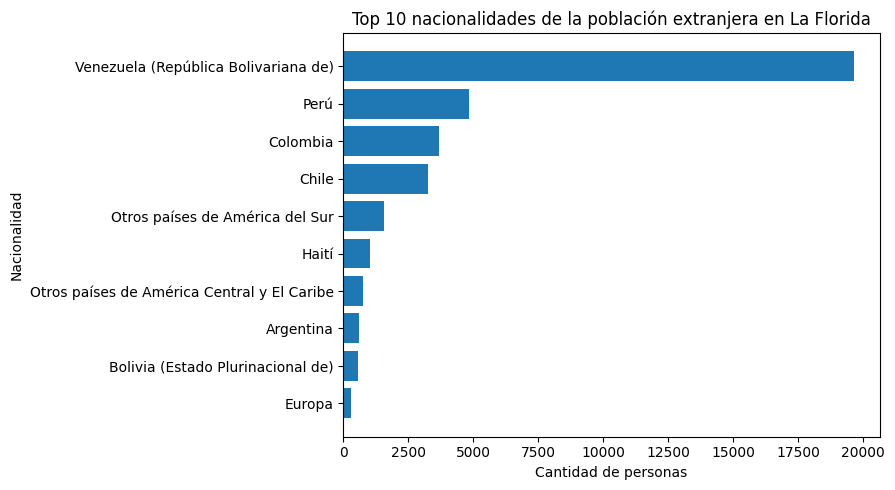

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(top_nacionalidades["nacionalidad"], top_nacionalidades["cantidad"])
plt.title("Top 10 nacionalidades de la población extranjera en La Florida")
plt.xlabel("Cantidad de personas")
plt.ylabel("Nacionalidad")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación
Con el gráfico obtenido podemos observar las nacionalidades extranjeras presentes en Chile, en donde podemos ver con claridad que la nacionalidad extranjera con mayor presencia en el pais es Venezuela con casi cerca de 20000 personas. Además, podemos observar que los países con mayor cantidad de personas en La Florida son paises de Latinoamérica. Por otro lado, es importante notar que en el gráfico aparece la categoría Chile, a pesar de que estamos analizando gente nacida en el extranjero. Esto ocurre porque la variable utilizada en esta seccóon `p27_nacionalidad_esp` , corresponde a la nacionalidad actual de la persona y no su lugar de naciomiemto. Por lo tanto, una persona puede haber nacido fuera de Chile, y al mismo tiempo,tener nacionalidad chilena.

## Parte 2.4: Período de llegada a Chile

En esta sección se analiza el período de llegada a Chile de la población nacida en el extranjero residente en La Florida, utilizando la variable `p26_llegada_periodo`.

Este indicador permite identificar si la llegada de la población migrante es más reciente o más antigua.

In [ ]:
df_mig[df_mig["origen"] == "Extranjero"]["p26_llegada_periodo"].value_counts(dropna=False).sort_index()

,count
p26_llegada_periodo,
1.0,3169
2.0,7117
3.0,14653
4.0,4731
5.0,1890
6.0,2750
7.0,1485
8.0,776
NaN,114


In [ ]:
tabla_personas_dic = pd.read_excel(
    "diccionario_variables_censo2024.xlsx",
    sheet_name="tabla_personas"
)

tabla_personas_dic.columns = tabla_personas_dic.columns.str.strip()

print("Columnas:")
print(tabla_personas_dic.columns.tolist())

tabla_personas_dic.head()

Columnas:
['Entidad', 'Nombre variable', 'Descripción de la variable', 'Valor', 'Etiqueta de categoría', 'Rango', 'Universo', 'Conteo']


,Entidad,Nombre variable,Descripción de la variable,Valor,Etiqueta de categoría,Rango,Universo,Conteo
0,Persona,id_vivienda,Llave identificadora de la vivienda o de la en...,1:7664466,Válidos,1:7664466,Todos los registros,18480432
1,Persona,id_hogar,Llave identificadora de hogar,0:26,Válidos,0:26,Todos los registros,18480432
2,Persona,id_persona,Llave identificadora de persona,0:5806,Válidos,0:5806,Todos los registros,18480432
3,Persona,region,Región,1:16,Ver diccionario códigos territoriales,1:16,Todos los registros,18480432
4,Persona,provincia,Provincia,11:163,Ver diccionario códigos territoriales,11:163,Todos los registros,18480432


In [ ]:
dic_p26 = tabla_personas_dic[
    tabla_personas_dic["Nombre variable"] == "p26_llegada_periodo"
][["Valor", "Etiqueta de categoría"]].copy()

dic_p26.columns = ["codigo_periodo", "periodo_llegada"]
dic_p26["codigo_periodo"] = pd.to_numeric(dic_p26["codigo_periodo"], errors="coerce")

llegada = (
    df_mig[df_mig["origen"] == "Extranjero"]["p26_llegada_periodo"]
    .dropna()
    .value_counts()
    .sort_index()
    .reset_index()
)

llegada.columns = ["codigo_periodo", "cantidad"]
llegada["codigo_periodo"] = pd.to_numeric(llegada["codigo_periodo"], errors="coerce")

llegada = llegada.merge(dic_p26, on="codigo_periodo", how="left")

llegada

,codigo_periodo,cantidad,periodo_llegada
0,1.0,3169,Entre 2023 y 2024
1,2.0,7117,Entre 2020 y 2022
2,3.0,14653,Entre 2017 y 2019
3,4.0,4731,Entre 2014 y 2016
4,5.0,1890,Entre 2010 y 2013
5,6.0,2750,Entre 2000 y 2009
6,7.0,1485,Entre 1990 y 1999
7,8.0,776,Antes de 1990


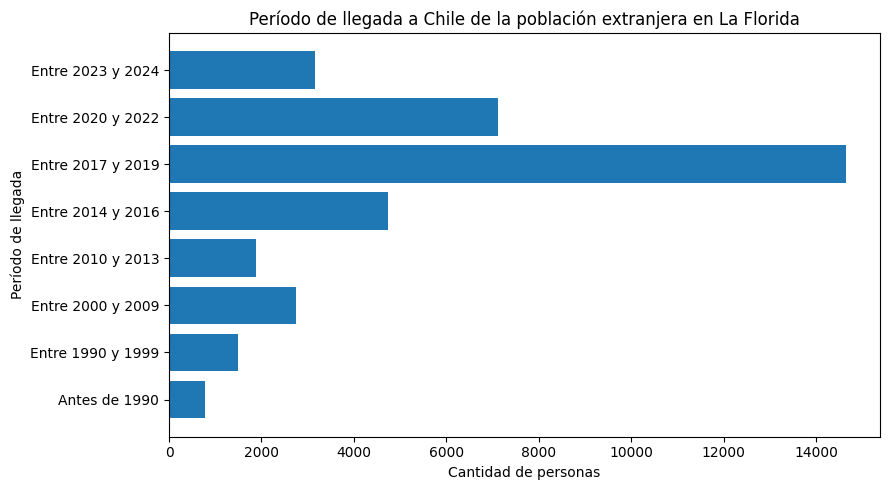

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(llegada["periodo_llegada"], llegada["cantidad"])
plt.title("Período de llegada a Chile de la población extranjera en La Florida")
plt.xlabel("Cantidad de personas")
plt.ylabel("Período de llegada")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación
El gráfico muestra que el período con mayor cantidad de personas corresponde a quienes lelgaron a Chile entre 2017 y 2019, lo que indica que ese fue el tramo temporal mpas relevante dentro de la composición migratoria actual de la comuna. En segundo lugar, destaca el grupo que llego entre el 2020 y el 2022, seguidos por quienes llegaron en el 2014 y 2016. Esto permite observar que una parte importante de la población nacida en el extranjero residente en La Florida se estableció en Chile durante la última década, especialmente desde mediados de los años 2010 en adelante.

## Parte 2.3: Lugar de residencia hace 5 años

En esta sección se analiza el lugar de residencia hace 5 años de la población nacida en el extranjero residente en La Florida, utilizando la variable `p24_lug_resid5`.

Este indicador permite aproximarse a la movilidad reciente de la población migrante y observar si las personas residían en la misma comuna, en otra comuna, en otro país o si aún no habían nacido.

In [ ]:
dic_p24 = tabla_personas_dic[
    tabla_personas_dic["Nombre variable"] == "p24_lug_resid5"
][["Valor", "Etiqueta de categoría"]].copy()

dic_p24

,Valor,Etiqueta de categoría
61,1,Aún no nacía
62,2,En esta comuna
63,3,En otra comuna
64,4,En otro país
65,-99,No respuesta


In [ ]:
resid_5 = (
    df_mig[df_mig["origen"] == "Extranjero"]["p24_lug_resid5"]
    .dropna()
    .value_counts()
    .sort_index()
    .reset_index()
)

resid_5.columns = ["codigo_resid_5", "cantidad"]
resid_5["codigo_resid_5"] = pd.to_numeric(resid_5["codigo_resid_5"], errors="coerce")

resid_5

,codigo_resid_5,cantidad
0,1.0,401
1,2.0,15343
2,3.0,9951
3,4.0,10958


In [ ]:
dic_p24.columns = ["codigo_resid_5", "residencia_5_anos"]
dic_p24["codigo_resid_5"] = pd.to_numeric(dic_p24["codigo_resid_5"], errors="coerce")

resid_5 = resid_5.merge(dic_p24, on="codigo_resid_5", how="left")

resid_5

,codigo_resid_5,cantidad,residencia_5_anos
0,1.0,401,Aún no nacía
1,2.0,15343,En esta comuna
2,3.0,9951,En otra comuna
3,4.0,10958,En otro país


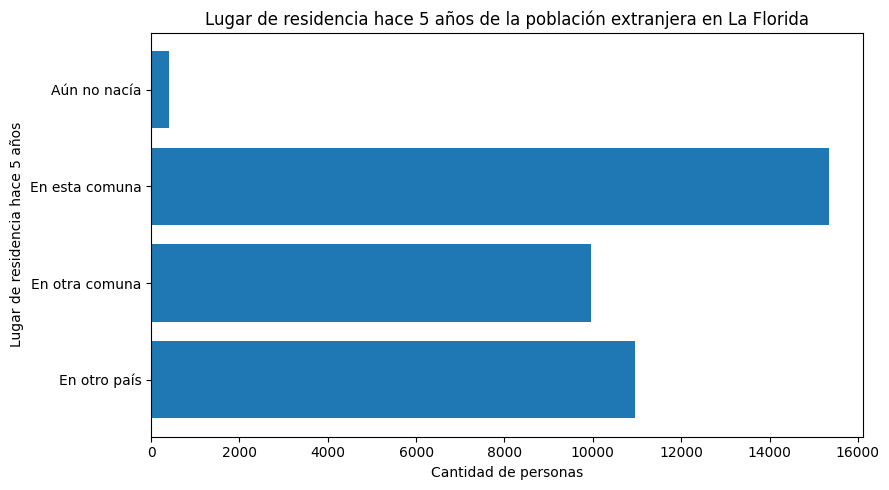

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(resid_5["residencia_5_anos"], resid_5["cantidad"])
plt.title("Lugar de residencia hace 5 años de la población extranjera en La Florida")
plt.xlabel("Cantidad de personas")
plt.ylabel("Lugar de residencia hace 5 años")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación

El gráfico sobre lugar de residencia hace 5 años muestra que una parte importante de la población extranjera que actualmente vive en La Florida ya residía en la misma comuna cinco años antes. Esta es la categoría con mayor frecuencia, lo que sugiere que una proporción relevante de la población migrante presenta cierta estabilidad territorial dentro de la comuna y no corresponde únicamente a llegadas o desplazamientos muy recientes.

Por otro lado, se observa un grupo considerable de personas que hace 5 años residía en otro país. Esto indica que una parte importante de la población extranjera llegó a Chile dentro de los últimos años, reforzando la idea de que la comuna ha recibido flujos migratorios recientes.



## Parte 3: Visualización espacial

En esta sección se utilizan datos geográficos de las comunas de Chile para construir dos mapas coropléticos: uno con la población total y otro con el porcentaje de población nacida en el extranjero.

Para ello, se une la información comunal calculada previamente con el shapefile de comunas, utilizando el código de comuna como llave de unión.

In [ ]:
comunas_gdf = gpd.read_file("comunas.shp")
comunas_gdf.head()

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-7992818.789 -4056669.319, -7992731...."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-7831651.813 -4022443.109, -7831596...."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-7892616.357 -4060673.364, -7892621...."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-7906457.717 -4051723.734, -7906266...."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-8121756.186 -4645860.295, -8121644...."


In [ ]:
comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")
tabla_foreign["codigo_comuna"] = pd.to_numeric(tabla_foreign["codigo_comuna"], errors="coerce")

mapa_gdf = comunas_gdf.merge(
    tabla_foreign,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

mapa_gdf[["cod_comuna", "Comuna", "codigo_comuna", "nombre_comuna", "pop_total", "pct_foreign"]]

,cod_comuna,Comuna,codigo_comuna,nombre_comuna,pop_total,pct_foreign
0,13110,La Florida,13110,La Florida,374836,9.786947


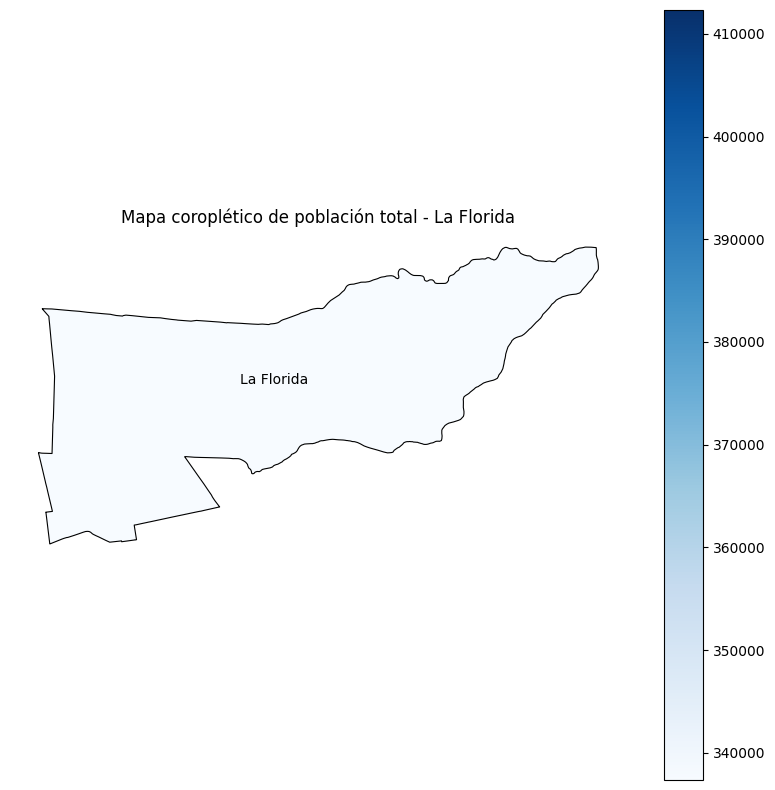

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

mapa_gdf.plot(
    column="pop_total",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in mapa_gdf.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(x, y, row["nombre_comuna"], fontsize=10, ha="center")

ax.set_title("Mapa coroplético de población total - La Florida")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Interpretación
Este mapa refuerza que La Florida constituye una comuna con un volumen poblacional elevado, lo que da contexto a los indicadores demográficos y migratorios calculados en las secciones anteriores. En otras palabras, no se trata de una comuna pequeña o marginal en términos poblacionales, sino de un territorio con una base demográfica amplia, lo que también ayuda a dimensionar la relevancia de fenómenos como la presencia de población extranjera, la estructura etaria y la inserción laboral observadas previamente.

En síntesis, este mapa cumple una función de localización territorial y de validación espacial del análisis, mostrando que el dato de población total fue correctamente vinculado con la comuna de La Florida dentro de la cartografía.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

mapa_gdf.plot(
    column="pct_foreign",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in mapa_gdf.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(x, y, row["nombre_comuna"], fontsize=10, ha="center")

ax.set_title("Mapa coroplético del porcentaje de población extranjera - La Florida")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Interpretación

El valor representado en el mapa corresponde a un 9,79% de población nacida en el extranjero, equivalente a 36.685 personas dentro de un total comunal de 374.836 habitantes. Esto indica que la presencia migrante en La Florida no es marginal, sino que constituye una fracción relevante de la estructura demográfica comunal.

Aunque el mapa no permite establecer comparaciones con otras comunas, sí permite reforzar visualmente que este porcentaje está territorialmente localizado en La Florida y forma parte de su realidad demográfica actual. En ese sentido, la representación espacial complementa los resultados anteriores, donde se observó que la población migrante en la comuna tiene una fuerte presencia latinoamericana, con predominio de nacionalidad venezolana, y una concentración importante en llegadas recientes al país.



## Parte 4: Tabla resumen final a nivel comuna

En esta sección se construye la tabla resumen final de la comuna de La Florida, integrando los principales indicadores demográficos y migratorios calculados en las secciones anteriores.

La tabla incluye población total, población nacida en Chile y en el extranjero, porcentaje de población extranjera, mediana de edad, escolaridad promedio, tasa de empleo y razón de dependencia.

In [ ]:
def build_summary(group):
    # Filtro base: Eliminar registros con edad faltante (-99)
    valid_age = group[group['edad'] != -99]

    # Segmentación por origen (1: Chileno, 2: Extranjero)
    # Basado en p25_lug_nacimiento_rec según pauta [cite: 131]
    chilean = valid_age[valid_age['p25_lug_nacimiento_rec'] == 1]
    foreign = valid_age[valid_age['p25_lug_nacimiento_rec'] == 2]

    # 1. Población
    pop_total = len(valid_age)
    pop_chilean = len(chilean)
    pop_foreign = len(foreign)
    pct_foreign = (pop_foreign / pop_total * 100) if pop_total > 0 else 0

    # 2. Mediana de edad
    median_age_chilean = chilean['edad'].median()
    median_age_foreign = foreign['edad'].median()

    # 3. Escolaridad (Solo 25+ años, excluyendo -99) [cite: 133, 134]
    esc_chilean = chilean[(chilean['edad'] >= 25) & (chilean['escolaridad'] != -99)]['escolaridad'].mean()
    esc_foreign = foreign[(foreign['edad'] >= 25) & (foreign['escolaridad'] != -99)]['escolaridad'].mean()

    # 4. Tasa de Empleo (15-64 años) [cite: 133, 134]
    # Nota: Se asume que el código para 'Ocupado' en sit_fuerza_trabajo es 1
    work_age_ch = chilean[(chilean['edad'] >= 15) & (chilean['edad'] <= 64)]
    work_age_fo = foreign[(foreign['edad'] >= 15) & (foreign['edad'] <= 64)]

    emp_rate_chilean = (len(work_age_ch[work_age_ch['sit_fuerza_trabajo'] == 1]) / len(work_age_ch)) if len(work_age_ch) > 0 else 0
    emp_rate_foreign = (len(work_age_fo[work_age_fo['sit_fuerza_trabajo'] == 1]) / len(work_age_fo)) if len(work_age_fo) > 0 else 0

    # 5. Razón de dependencia (0-14 + 65+) / (15-64) [cite: 56, 57]
    pob_dep = len(valid_age[(valid_age['edad'] < 15) | (valid_age['edad'] >= 65)])
    pob_prod = len(valid_age[(valid_age['edad'] >= 15) & (valid_age['edad'] <= 64)])
    dependency_ratio = (pob_dep / pob_prod) if pob_prod > 0 else 0

    return pd.Series({
        'nombre_comuna': group['nombre_comuna'].iloc[0],
        'pop_total': pop_total,
        'pop_chilean': pop_chilean,
        'pop_foreign': pop_foreign,
        'pct_foreign': pct_foreign,
        'median_age_chilean': median_age_chilean,
        'median_age_foreign': median_age_foreign,
        'mean_schooling_chilean': esc_chilean,
        'mean_schooling_foreign': esc_foreign,
        'emp_rate_chilean': emp_rate_chilean,
        'emp_rate_foreign': emp_rate_foreign,
        'dependency_ratio': dependency_ratio
    })

# Generar tabla final y guardar CSV para Tarea 3 [cite: 105, 107]
summary_table = df.groupby("codigo_comuna").apply(build_summary).reset_index()
summary_table.to_csv("tareal_comuna_summary.csv", index=False)

# Mostrar resultado
summary_table

/tmp/ipykernel_536/1965795521.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_table = df.groupby("codigo_comuna").apply(build_summary).reset_index()


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13110,La Florida,374836,335340,36685,9.786947,38.0,34.0,12.846742,13.965309,0.65993,0.787858,0.468063


# **Análisis Demográfico y Migratorio**

1. **Estructura Etaria y Migración:** Se observa que la población extranjera suele presentar una mediana de edad menor que la población chilena. Esto es característico de los procesos migratorios recientes, compuestos principalmente por adultos en edad laboral activa.

2. **Capital Humano:** Al comparar los años de escolaridad promedio (población 25+), es común encontrar que la población extranjera posee niveles educativos similares o incluso superiores a la local, lo que sugiere una migración calificada que busca integrarse al mercado laboral de la comuna.

3. **Mercado Laboral:** La tasa de empleo en el rango de 15-64 años suele ser mayor en el grupo extranjero. Esto se explica porque el principal motivo de residencia es económico, lo que implica una mayor presión por insertarse rápidamente en la fuerza de trabajo en comparación con la población local, que incluye más estudiantes o personas fuera de la fuerza laboral por otros motivos.

4. **Carga Demográfica:** La razón de dependencia refleja cuánta población "inactiva" (niños y adultos mayores) depende de la población en edad de trabajar. Una proporción alta de inmigrantes jóvenes tiende a "aliviar" esta carga en la comuna, inyectando dinamismo a la base productiva.